## Installation et Import des librairies

In [1]:
# Installation des dépendances
!pip install osmnx geopandas folium matplotlib seaborn pandas numpy requests -q

In [2]:
import osmnx as ox
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import folium
import requests
import warnings
warnings.filterwarnings('ignore')

# Style global
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid')


## 2. Collecte des données — OpenStreetMap

On utilise `osmnx` pour extraire tous les bâtiments historiques des 4 villes cibles.

In [3]:
VILLES = ['Tunis, Tunisia', 'Sfax, Tunisia', 'Kairouan, Tunisia', 'Sousse, Tunisia']

TAGS = {
    'historic': True,
    'building': ['mosque', 'cathedral', 'church', 'synagogue', 'temple'],
    'amenity': 'place_of_worship',
    'tourism': ['museum']
}

dfs = []
for ville in VILLES:
    print(f'📍 Extraction de {ville}...')
    try:
        gdf = ox.features_from_place(ville, tags=TAGS)
        gdf['ville'] = ville.split(',')[0]
        dfs.append(gdf)
        print(f'   → {len(gdf)} éléments trouvés')
    except Exception as e:
        print(f'   Erreur : {e}')

gdf_all = pd.concat(dfs, ignore_index=True)
print(f'\n Total : {len(gdf_all)} bâtiments historiques collectés')

📍 Extraction de Tunis, Tunisia...
   → 4522 éléments trouvés
📍 Extraction de Sfax, Tunisia...
   → 389 éléments trouvés
📍 Extraction de Kairouan, Tunisia...
   → 267 éléments trouvés
📍 Extraction de Sousse, Tunisia...
   → 72 éléments trouvés

 Total : 5250 bâtiments historiques collectés


In [4]:
# Aperçu des colonnes disponibles
print('Colonnes disponibles :', gdf_all.columns.tolist())
print('\nAperçu des données :')
gdf_all.head()

Colonnes disponibles : ['geometry', 'historic', 'name', 'name:ar', 'name:en', 'name:fr', 'wikidata', 'wikipedia', 'access', 'historic:civilization', 'inscription', 'ruins', 'archaeological_site', 'description', 'amenity', 'building', 'religion', 'denomination', 'service_times', 'wheelchair', 'castle_type', 'addr:city', 'tourism', 'name:ca', 'name:it', 'name:de', 'name:la', 'addr:postcode', 'addr:street', 'man_made', 'ref:nga', 'seamark:light:1:character', 'seamark:light:1:colour', 'seamark:light:1:group', 'seamark:light:1:height', 'seamark:light:1:period', 'seamark:light:1:range', 'seamark:light:1:sector_end', 'seamark:light:1:sector_start', 'seamark:light:1:sequence', 'seamark:light:2:character', 'seamark:light:2:colour', 'seamark:light:2:group', 'seamark:light:2:height', 'seamark:light:2:period', 'seamark:light:2:range', 'seamark:light:2:sector_end', 'seamark:light:2:sector_start', 'seamark:light:2:sequence', 'seamark:light:reference', 'seamark:name', 'seamark:type', 'source', 'year_

,geometry,historic,name,name:ar,name:en,name:fr,wikidata,wikipedia,access,historic:civilization,...,name:ro,addr:neighbourhood,alt_name:cs,name:cs,contact:facebook,source:url,heritage:ref,heritage:website,whc:name,ville
0,POINT (10.17287 36.60692),ruins,Uthina / Oudhna,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Tunis
1,POINT (10.3243 36.85357),NaN,المتحف الوطني بقرطاج,المتحف الوطني بقرطاج,Carthage National Museum,Musée National de Carthage,Q1961849,es:Museo Nacional de Cartago,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Tunis
2,POINT (10.83306 35.77363),monument,Statue Bourguiba,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Tunis
3,POINT (10.26235 32.91235),ruins,Ksar Chenini,NaN,NaN,NaN,Q73805419,en:Ksar Chenini,yes,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Tunis
4,POINT (10.85939 33.81392),NaN,الغريبة,الغريبة,El Ghriba Synagogue,Synagogue de la Ghriba,Q311734,en:El Ghriba synagogue,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Tunis


## 3. Nettoyage initial

In [5]:
# Sélection des colonnes utiles
cols_utiles = ['ville', 'historic', 'building', 'amenity', 'tourism',
               'name', 'name:ar', 'geometry']
cols_presentes = [c for c in cols_utiles if c in gdf_all.columns]
df = gdf_all[cols_presentes].copy()

# Garder uniquement les polygones (bâtiments avec surface)
df = df[df.geometry.geom_type.isin(['Polygon', 'MultiPolygon'])].copy()

# Calcul du centroïde pour les coordonnées
df['lat'] = df.geometry.centroid.y
df['lon'] = df.geometry.centroid.x

# Calcul de la surface en m²
df_proj = df.to_crs('EPSG:32632')  # Projection métrique
df['surface_m2'] = df_proj.geometry.area

print(f'Bâtiments polygones : {len(df)}')
print(f'\nValeurs manquantes :')
print(df.isnull().sum())

Bâtiments polygones : 2770

Valeurs manquantes :
ville            0
historic      1568
building       937
amenity       1507
tourism       2683
name           925
name:ar       1909
geometry         0
lat              0
lon              0
surface_m2       0
dtype: int64


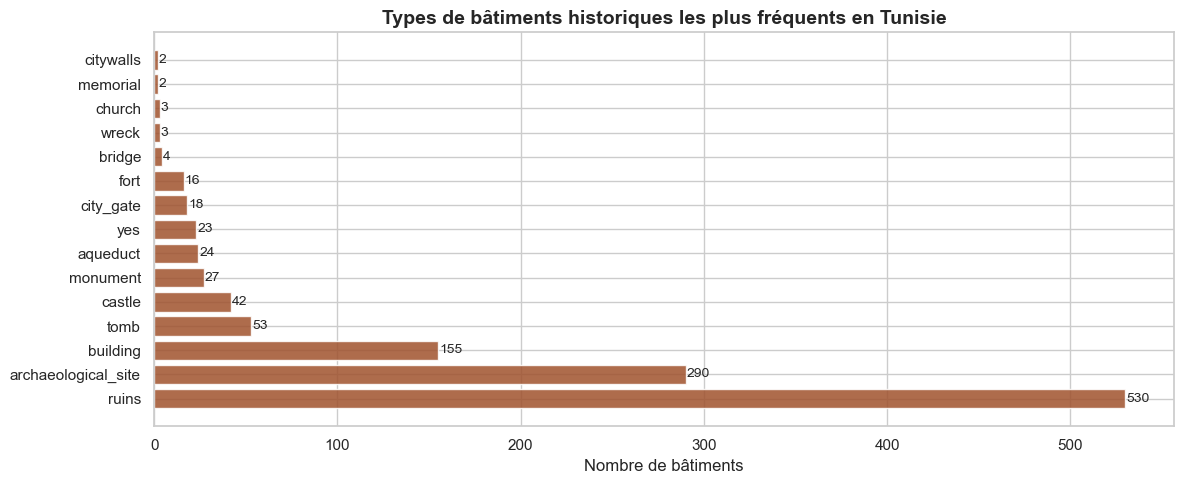

In [6]:
# Distribution par type historique
if 'historic' in df.columns:
    type_counts = df['historic'].value_counts().head(15)
    
    fig, ax = plt.subplots(figsize=(12, 5))
    bars = ax.barh(type_counts.index, type_counts.values, color='#A0522D', alpha=0.85)
    ax.set_xlabel('Nombre de bâtiments', fontsize=12)
    ax.set_title('Types de bâtiments historiques les plus fréquents en Tunisie', 
                 fontsize=14, fontweight='bold')
    for bar, val in zip(bars, type_counts.values):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                str(val), va='center', fontsize=10)
    plt.tight_layout()
    plt.savefig('types_batiments.png', dpi=150, bbox_inches='tight')
    plt.show()

## 4. Distribution par ville

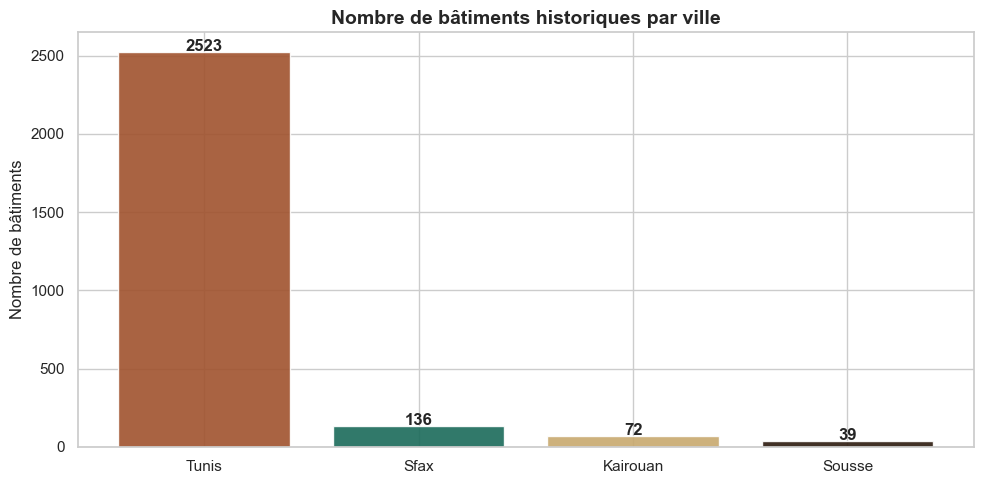

ville
Tunis       2523
Sfax         136
Kairouan      72
Sousse        39
Name: count, dtype: int64


In [7]:
# Nombre de bâtiments par ville
ville_counts = df['ville'].value_counts()

couleurs = ['#A0522D', '#1A6B5A', '#C8A96E', '#2C1A0E']
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(ville_counts.index, ville_counts.values, color=couleurs, alpha=0.9, edgecolor='white')

for bar, val in zip(bars, ville_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(val), ha='center', fontweight='bold', fontsize=12)

ax.set_title('Nombre de bâtiments historiques par ville', fontsize=14, fontweight='bold')
ax.set_ylabel('Nombre de bâtiments')
plt.tight_layout()
plt.savefig('batiments_par_ville.png', dpi=150, bbox_inches='tight')
plt.show()
print(ville_counts)

## 5. Carte interactive — Distribution géographique

In [8]:
# Carte folium des bâtiments historiques
couleurs_villes = {
    'Tunis': 'red',
    'Sfax': 'blue',
    'Kairouan': 'green',
    'Sousse': 'orange'
}

m = folium.Map(location=[34.0, 9.5], zoom_start=7, tiles='CartoDB positron')

for _, row in df.iterrows():
    ville = row.get('ville', 'Autre')
    couleur = couleurs_villes.get(ville, 'gray')
    nom = row.get('name', 'Inconnu')
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=4,
        color=couleur,
        fill=True,
        fill_color=couleur,
        fill_opacity=0.7,
        tooltip=f"{nom} ({ville})"
    ).add_to(m)

# Légende
legend_html = '''
<div style="position:fixed;bottom:30px;left:30px;background:white;padding:12px;
            border-radius:8px;box-shadow:2px 2px 6px rgba(0,0,0,0.3);font-size:13px;">
<b> Villes</b><br>
<span style="color:red">●</span> Tunis<br>
<span style="color:blue">●</span> Sfax<br>
<span style="color:green">●</span> Kairouan<br>
<span style="color:orange">●</span> Sousse
</div>
'''
m.get_root().html.add_child(folium.Element(legend_html))
m.save('carte_batiments.html')
print(' Carte sauvegardée : carte_batiments.html')
m

 Carte sauvegardée : carte_batiments.html


## 6. Analyse des surfaces

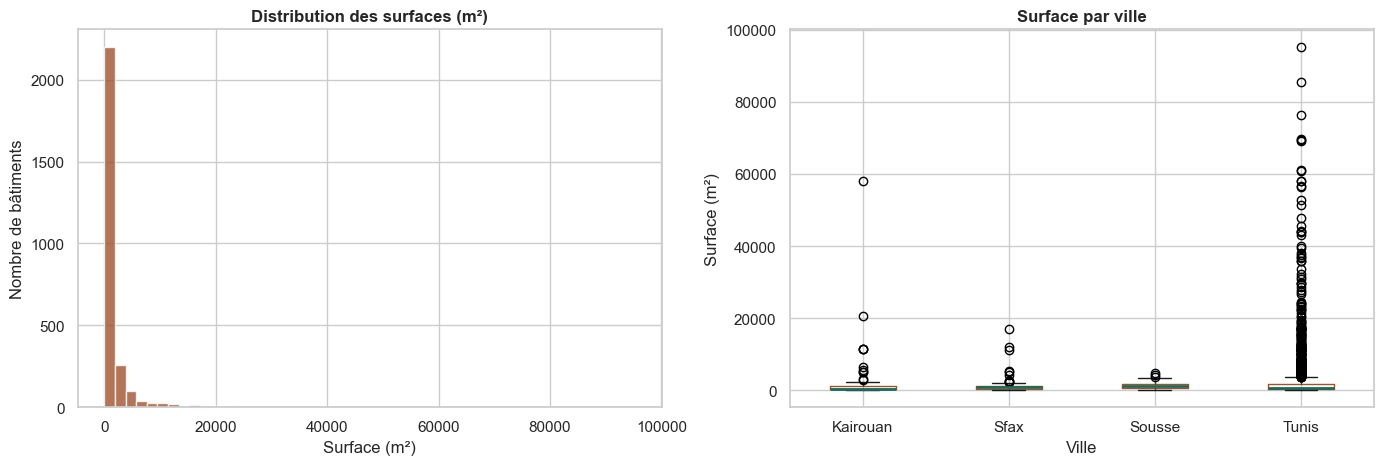

Statistiques descriptives des surfaces :
           count    mean     std   min    25%     50%     75%      max
ville                                                                 
Kairouan    69.0  2443.6  7597.4  33.8  193.0   402.5  1053.7  57924.8
Sfax       135.0  1181.0  2041.6   4.3  428.5   759.0  1097.6  16941.6
Sousse      39.0  1305.4  1119.8  79.3  511.8  1173.4  1684.7   4659.7
Tunis     2499.0  2308.4  6664.9   2.3  253.7   651.0  1634.6  95357.3


In [9]:
# Distribution des surfaces
df_clean = df[df['surface_m2'] < df['surface_m2'].quantile(0.99)].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme global
axes[0].hist(df_clean['surface_m2'], bins=50, color='#A0522D', alpha=0.8, edgecolor='white')
axes[0].set_title('Distribution des surfaces (m²)', fontweight='bold')
axes[0].set_xlabel('Surface (m²)')
axes[0].set_ylabel('Nombre de bâtiments')

# Boxplot par ville
df_clean.boxplot(column='surface_m2', by='ville', ax=axes[1],
                  boxprops=dict(color='#A0522D'),
                  medianprops=dict(color='#1A6B5A', linewidth=2))
axes[1].set_title('Surface par ville', fontweight='bold')
axes[1].set_xlabel('Ville')
axes[1].set_ylabel('Surface (m²)')
plt.suptitle('')

plt.tight_layout()
plt.savefig('surfaces_batiments.png', dpi=150, bbox_inches='tight')
plt.show()

print('Statistiques descriptives des surfaces :')
print(df_clean.groupby('ville')['surface_m2'].describe().round(1))

## 7. Sauvegarde des données brutes

In [10]:
# Sauvegarde
df_save = df.drop(columns=['geometry']).copy()
df_save.to_csv('data_brute_osm.csv', index=False, encoding='utf-8')
print(f' Dataset brut sauvegardé : {len(df_save)} lignes × {len(df_save.columns)} colonnes')
df_save.head()

 Dataset brut sauvegardé : 2770 lignes × 10 colonnes


,ville,historic,building,amenity,tourism,name,name:ar,lat,lon,surface_m2
1975,Tunis,castle,yes,NaN,NaN,حصن حلق الوادي,حصن حلق الوادي,36.814462,10.303612,8485.262018
1976,Tunis,yes,mosque,place_of_worship,NaN,جامع القيروان الكبير,جامع القيروان الكبير,35.681528,10.104006,6373.458076
1977,Tunis,NaN,yes,place_of_worship,NaN,الجامع الكبير,الجامع الكبير,35.503860,11.072058,2778.399206
1978,Tunis,NaN,mosque,place_of_worship,NaN,الجامع الكبير بسوسة,الجامع الكبير بسوسة,35.826831,10.639746,2097.122198
1979,Tunis,archaeological_site,ruins,NaN,NaN,Uthina Amphitheatre,NaN,36.608621,10.169238,6560.163587
